<a href="https://colab.research.google.com/github/gopalstud86/GenAI-Assignments/blob/main/Bronze%20Badge%20Assignments/Problem1_EmpProductivityScore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [37]:
dataset_url = "https://raw.githubusercontent.com/gopalstud86/GenAI-Assignments/refs/heads/main/Bronze%20Badge%20Assignments/Datasets/employee_productivity.csv"

data = pd.read_csv(dataset_url)
df = pd.DataFrame(data)
df.head()

,Experience,TrainingHours,WorkingHours,Projects,ProductivityScore
0,7,99,58,10,87.44
1,20,76,36,10,100.00
2,15,28,34,1,71.96
3,11,29,51,6,66.39
4,8,80,58,7,65.50


In [38]:
df['Experience_In_hrs'] = df['Experience'].astype(int)
df['TrainingHours'] = df['TrainingHours'].astype(int)
df['WorkingHours'] = df['WorkingHours'].astype(int)
df['Projects'] = df['Projects'].astype(int)

df.drop(columns=['Experience'], inplace=True)
#df.rename(columns={'Experience_In_hrs': 'Experience'}, inplace=True)

X = df[["Experience_In_hrs", "TrainingHours", "WorkingHours", "Projects"]]
y = df["ProductivityScore"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
model = LinearRegression()
model.fit(X_train, y_train)


print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

Intercept: 57.82738567558491
Coefficients:
  Experience_In_hrs: 1.98
  TrainingHours: 0.24
  WorkingHours: -0.63
  Projects: 2.45


In [40]:
y_pred = model.predict(X_test)
print("\nR2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.8927404456281272
RMSE: 5.656032769980623


In [41]:

new_employee = [[4, 50, 40, 5]]  # Example input
predicted_score = model.predict(new_employee)
print("\nPredicted Productivity Score for new employee:", predicted_score[0])



Predicted Productivity Score for new employee: 64.7953967151825


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
corr_matrix = df.corr()

print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
                    TrainingHours  WorkingHours  Projects  ProductivityScore  \
TrainingHours           1.000000      0.039231  0.066127           0.366891   
WorkingHours            0.039231      1.000000 -0.045085          -0.373315   
Projects                0.066127     -0.045085  1.000000           0.503768   
ProductivityScore       0.366891     -0.373315  0.503768           1.000000   
Experience_In_hrs       0.052806     -0.113958  0.065633           0.714769   

                   Experience_In_hrs  
TrainingHours               0.052806  
WorkingHours               -0.113958  
Projects                    0.065633  
ProductivityScore           0.714769  
Experience_In_hrs           1.000000  


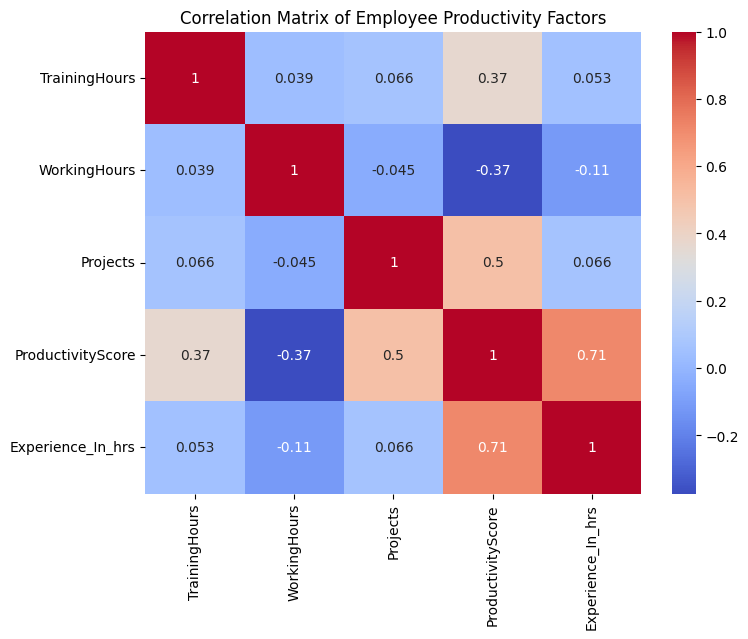

In [44]:

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Employee Productivity Factors")
plt.show()


***Interpretation based on the given data. It can vary when data is large or changed.***

1. Which factor most strongly impacts productivity?

Experience (0.71 correlation) is the strongest driver of productivity. Employees with more years of experience consistently show higher productivity scores.

2. How does training affect productivity?

Training has a positive but weaker effect (0.37 correlation). It helps improve productivity, but not as much as experience or projects. Training is best seen as a supportive factor that enhances skills rather than the main driver.

3. Should the company increase training hours or working hours?

Increase training hours. Training builds long-term capability and has a positive correlation with productivity.

Avoid increasing working hours beyond ~45 per week, because working hours show a negative correlation (-0.37) with productivity — more hours lead to fatigue and reduced efficiency.

4. What happens if Working Hours increase beyond optimal limits?

Productivity declines. The negative correlation indicates that pushing employees to work longer hours reduces their output due to burnout, stress, and errors.

5. Can productivity ever decrease with more experience?

Generally, experience increases productivity. But in practice, productivity can decline if experienced employees don’t keep their skills updated or resist new methods. That’s why continuous training is essential to complement experience.

6. How would you detect overfitting in this model?

Compare R2 scores on training vs test sets — a large gap means overfitting.


7. Suggest one new feature to improve prediction accuracy.

Add an Employee Engagement/Motivation Score (survey-based). Productivity isn’t just about hours and projects — motivation and morale strongly influence output. Including engagement would capture human factors and improve prediction accuracy.